# Flight Delay Baseline Model

This notebook reads the existing model ready Parquet datasets, creates a simple benchmark, trains the first SageMaker model, evaluates it against the benchmark and prepares the model for deployment.

In [1]:
import boto3
import awswrangler as wr
import pandas as pd

from IPython.display import display

region = boto3.Session().region_name or "us-east-1"
account_id = boto3.client("sts").get_caller_identity()["Account"]

athena_db = "aai540_group1"
athena_s3_output = (
    f"s3://aws-athena-query-results-{account_id}-{region}/"
)

required_tables = [
    "flight_delay_train_2025",
    "flight_delay_validation_2025",
    "flight_delay_test_2025",
    "flight_delay_production_2025"
]

for table in required_tables:
    exists = wr.catalog.does_table_exist(
        database=athena_db,
        table=table
    )
    print(f"{table}: {'AVAILABLE' if exists else 'MISSING'}")

flight_delay_train_2025: AVAILABLE
flight_delay_validation_2025: AVAILABLE
flight_delay_test_2025: AVAILABLE
flight_delay_production_2025: AVAILABLE


## Team Responsibility: Denis Mulabegovic
**Benchmark and Initial Model**

Covers the majority-class benchmark and the first machine learning model setup.


### Majority Class Benchmark

A simple majority class classifier is used as the benchmark. It predicts the most common training label for every flight. Accuracy, balanced accuracy, recall and F1 score are recorded so the trained model can later be evaluated against this baseline.

In [2]:
training_distribution = wr.athena.read_sql_query(
    """
    SELECT
        delayed,
        COUNT(*) AS records,
        ROUND(
            100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
            2
        ) AS percentage
    FROM flight_delay_train_2025
    GROUP BY delayed
    ORDER BY records DESC
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(training_distribution)

majority_class = int(training_distribution.iloc[0]["delayed"])

print("Majority class:", majority_class)
print(
    "Benchmark prediction:",
    "Delayed" if majority_class == 1 else "Not delayed"
)

2026-09-23 12:23:04,654	WARNING services.py:2213 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 408924160 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.98gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-09-23 12:23:06,872	INFO worker.py:2012 -- Started a local Ray instance.
/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


,delayed,records,percentage
0,0,2214442,79.47
1,1,571908,20.53


Majority class: 0
Benchmark prediction: Not delayed


In [3]:
evaluation_counts = wr.athena.read_sql_query(
    """
    SELECT
        'Validation' AS dataset,
        COUNT(*) AS total_records,
        COUNT_IF(delayed = 0) AS actual_not_delayed,
        COUNT_IF(delayed = 1) AS actual_delayed
    FROM flight_delay_validation_2025

    UNION ALL

    SELECT
        'Test',
        COUNT(*),
        COUNT_IF(delayed = 0),
        COUNT_IF(delayed = 1)
    FROM flight_delay_test_2025
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(evaluation_counts)

,dataset,total_records,actual_not_delayed,actual_delayed
0,Test,612811,435799,177012
1,Validation,599472,430067,169405


In [4]:
benchmark_results = []

for _, row in evaluation_counts.iterrows():
    total = int(row["total_records"])
    negative = int(row["actual_not_delayed"])
    positive = int(row["actual_delayed"])

    if majority_class == 0:
        true_negative = negative
        false_negative = positive
        true_positive = 0
        false_positive = 0
    else:
        true_negative = 0
        false_negative = 0
        true_positive = positive
        false_positive = negative

    accuracy = (
        true_positive + true_negative
    ) / total

    recall = (
        true_positive / (true_positive + false_negative)
        if true_positive + false_negative > 0
        else 0
    )

    precision = (
        true_positive / (true_positive + false_positive)
        if true_positive + false_positive > 0
        else 0
    )

    specificity = (
        true_negative / (true_negative + false_positive)
        if true_negative + false_positive > 0
        else 0
    )

    balanced_accuracy = (recall + specificity) / 2

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0
    )

    benchmark_results.append({
        "dataset": row["dataset"],
        "accuracy": round(accuracy, 4),
        "balanced_accuracy": round(balanced_accuracy, 4),
        "delayed_precision": round(precision, 4),
        "delayed_recall": round(recall, 4),
        "delayed_f1": round(f1, 4)
    })

benchmark_results = pd.DataFrame(benchmark_results)

display(benchmark_results)

,dataset,accuracy,balanced_accuracy,delayed_precision,delayed_recall,delayed_f1
0,Test,0.7111,0.5,0,0.0,0
1,Validation,0.7174,0.5,0,0.0,0


## First Machine Learning Model

The first trained model will use SageMaker XGBoost with numerical features that are available before departure. This provides a reproducible first model while avoiding target leakage. Its validation and test performance will be compared against the majority class benchmark.

In [5]:
target_column = "delayed"

model_features = [
    "month",
    "day_of_month",
    "day_of_week",
    "is_weekend",
    "scheduled_departure_hour",
    "scheduled_arrival_hour",
    "scheduled_duration",
    "distance"
]

print("Target:", target_column)
print("Model features:", model_features)
print("Number of features:", len(model_features))

Target: delayed
Model features: ['month', 'day_of_month', 'day_of_week', 'is_weekend', 'scheduled_departure_hour', 'scheduled_arrival_hour', 'scheduled_duration', 'distance']
Number of features: 8


In [6]:
model_data_check = wr.athena.read_sql_query(
    """
    WITH modeling_data AS (
        SELECT
            'Training' AS dataset,
            month,
            day_of_month,
            day_of_week,
            is_weekend,
            scheduled_departure_hour,
            scheduled_arrival_hour,
            scheduled_duration,
            distance,
            delayed
        FROM flight_delay_train_2025

        UNION ALL

        SELECT
            'Validation',
            month,
            day_of_month,
            day_of_week,
            is_weekend,
            scheduled_departure_hour,
            scheduled_arrival_hour,
            scheduled_duration,
            distance,
            delayed
        FROM flight_delay_validation_2025

        UNION ALL

        SELECT
            'Test',
            month,
            day_of_month,
            day_of_week,
            is_weekend,
            scheduled_departure_hour,
            scheduled_arrival_hour,
            scheduled_duration,
            distance,
            delayed
        FROM flight_delay_test_2025
    )

    SELECT
        dataset,
        COUNT(*) AS records,

        COUNT_IF(
            month IS NULL
            OR day_of_month IS NULL
            OR day_of_week IS NULL
            OR is_weekend IS NULL
            OR scheduled_departure_hour IS NULL
            OR scheduled_arrival_hour IS NULL
            OR scheduled_duration IS NULL
            OR distance IS NULL
            OR delayed IS NULL
        ) AS incomplete_records,

        ROUND(
            100.0 * AVG(CAST(delayed AS DOUBLE)),
            2
        ) AS delay_rate_pct

    FROM modeling_data
    GROUP BY dataset
    ORDER BY dataset
    """,
    database=athena_db,
    s3_output=athena_s3_output
)

display(model_data_check)

,dataset,records,incomplete_records,delay_rate_pct
0,Test,612811,0,28.89
1,Training,2786350,0,20.53
2,Validation,599472,0,28.26


## Team Responsibility: Thomas Geraci
**SageMaker Data Preparation and Model Training**

Covers preparing the data for SageMaker XGBoost and training the SageMaker model.


## Prepare Data for SageMaker XGBoost

The training and validation records will be exported from Athena to S3 in the format required by SageMaker XGBoost. The target column will appear first, followed by the eight numerical features.

In [7]:
model_bucket = f"sagemaker-aai540-modeling-{account_id}"
model_prefix = "flight-delay-xgboost"

train_s3_path = f"s3://{model_bucket}/{model_prefix}/data/train/"
validation_s3_path = f"s3://{model_bucket}/{model_prefix}/data/validation/"
test_s3_path = f"s3://{model_bucket}/{model_prefix}/data/test/"
model_output_path = f"s3://{model_bucket}/{model_prefix}/model-output/"

print("Model bucket:", model_bucket)
print("Training path:", train_s3_path)
print("Validation path:", validation_s3_path)
print("Test path:", test_s3_path)
print("Model output:", model_output_path)

Model bucket: sagemaker-aai540-modeling-697977302576
Training path: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/data/train/
Validation path: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/data/validation/
Test path: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/data/test/
Model output: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/model-output/


In [8]:
from botocore.exceptions import ClientError

s3_client = boto3.client("s3", region_name=region)

try:
    s3_client.create_bucket(Bucket=model_bucket)
    print("Modeling bucket created.")
except ClientError as error:
    error_code = error.response["Error"]["Code"]

    if error_code == "BucketAlreadyOwnedByYou":
        print("Modeling bucket already exists.")
    else:
        raise

s3_client.put_public_access_block(
    Bucket=model_bucket,
    PublicAccessBlockConfiguration={
        "BlockPublicAcls": True,
        "IgnorePublicAcls": True,
        "BlockPublicPolicy": True,
        "RestrictPublicBuckets": True
    }
)

s3_client.put_bucket_encryption(
    Bucket=model_bucket,
    ServerSideEncryptionConfiguration={
        "Rules": [
            {
                "ApplyServerSideEncryptionByDefault": {
                    "SSEAlgorithm": "AES256"
                }
            }
        ]
    }
)

print("Public access blocked.")
print("SSE-S3 encryption enabled.")
print("Modeling bucket ready:", model_bucket)

Modeling bucket created.
Public access blocked.
SSE-S3 encryption enabled.
Modeling bucket ready: sagemaker-aai540-modeling-697977302576


In [9]:
export_datasets = {
    "Training": (
        "flight_delay_train_2025",
        train_s3_path
    ),
    "Validation": (
        "flight_delay_validation_2025",
        validation_s3_path
    ),
    "Test": (
        "flight_delay_test_2025",
        test_s3_path
    )
}

ordered_columns = [target_column] + model_features
select_columns = ",\n        ".join(ordered_columns)

for dataset_name, (table_name, output_path) in export_datasets.items():
    existing_files = wr.s3.list_objects(output_path)

    if existing_files:
        print(
            f"{dataset_name}: export already exists "
            f"({len(existing_files)} files). Skipping."
        )
        continue

    export_query = f"""
    UNLOAD (
        SELECT
            {select_columns}
        FROM "{athena_db}"."{table_name}"
    )
    TO '{output_path}'
    WITH (
        format = 'TEXTFILE',
        field_delimiter = ','
    )
    """

    print(f"Exporting {dataset_name} data...")

    wr.athena.start_query_execution(
        sql=export_query,
        database=athena_db,
        s3_output=athena_s3_output,
        wait=True
    )

    exported_files = wr.s3.list_objects(output_path)

    print(
        f"{dataset_name}: complete "
        f"({len(exported_files)} files)"
    )

print("All modeling datasets are ready.")

Exporting Training data...
Training: complete (1 files)
Exporting Validation data...
Validation: complete (1 files)
Exporting Test data...
Test: complete (1 files)
All modeling datasets are ready.


In [10]:
import gzip
import io

export_summary = []

for dataset_name, (_, s3_path) in export_datasets.items():
    files = wr.s3.list_objects(s3_path)
    file_path = files[0]

    bucket_name, object_key = file_path.replace(
        "s3://", ""
    ).split("/", 1)

    object_info = s3_client.head_object(
        Bucket=bucket_name,
        Key=object_key
    )

    response = s3_client.get_object(
        Bucket=bucket_name,
        Key=object_key
    )

    with gzip.GzipFile(fileobj=response["Body"]) as compressed_file:
        sample_lines = [
            compressed_file.readline().decode("utf-8")
            for _ in range(5)
        ]

    sample = pd.read_csv(
        io.StringIO("".join(sample_lines)),
        header=None,
        names=ordered_columns
    )

    export_summary.append({
        "dataset": dataset_name,
        "files": len(files),
        "size_mb": round(
            object_info["ContentLength"] / (1024 ** 2),
            2
        ),
        "columns": sample.shape[1]
    })

    print(f"\n{dataset_name} sample:")
    display(sample)

export_summary = pd.DataFrame(export_summary)
display(export_summary)


Training sample:


,delayed,month,day_of_month,day_of_week,is_weekend,scheduled_departure_hour,scheduled_arrival_hour,scheduled_duration,distance
0,0,2,12,3,0,19,20,192.0,1055.0
1,0,2,12,3,0,21,5,263.0,2106.0
2,1,2,12,3,0,5,6,77.0,447.0
3,0,2,12,3,0,16,19,200.0,1237.0
4,0,2,12,3,0,20,23,217.0,1237.0



Validation sample:


,delayed,month,day_of_month,day_of_week,is_weekend,scheduled_departure_hour,scheduled_arrival_hour,scheduled_duration,distance
0,1,6,10,2,0,7,9,276.0,1888.0
1,0,6,10,2,0,17,23,229.0,1590.0
2,0,6,10,2,0,17,21,242.0,1391.0
3,0,6,10,2,0,12,17,243.0,1391.0
4,0,6,10,2,0,7,10,228.0,1389.0



Test sample:


,delayed,month,day_of_month,day_of_week,is_weekend,scheduled_departure_hour,scheduled_arrival_hour,scheduled_duration,distance
0,0,7,10,4,0,9,10,80.0,338.0
1,1,7,10,4,0,20,23,140.0,909.0
2,1,7,10,4,0,13,15,85.0,358.0
3,0,7,10,4,0,17,19,85.0,358.0
4,1,7,10,4,0,10,12,260.0,1791.0


,dataset,files,size_mb,columns
0,Training,1,15.02,9
1,Validation,1,3.23,9
2,Test,1,3.31,9


## Train the SageMaker XGBoost Model

A managed SageMaker training job will train an XGBoost binary classifier. Class weighting will be used because delayed flights are less common than non delayed flights.

In [13]:
from datetime import datetime, timezone

try:
    from sagemaker.core import image_uris
except ImportError:
    from sagemaker import image_uris

sagemaker_client = boto3.client(
    "sagemaker",
    region_name=region
)

xgboost_image_uri = image_uris.retrieve(
    "xgboost",
    region,
    "1.7-1"
)

training_job_name = (
    "flight-delay-xgboost-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

negative_records = 2214442
positive_records = 571908

scale_pos_weight = round(
    negative_records / positive_records,
    2
)

hyperparameters = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "max_depth": "5",
    "eta": "0.1",
    "min_child_weight": "1",
    "subsample": "0.8",
    "colsample_bytree": "0.8",
    "scale_pos_weight": str(scale_pos_weight),
    "num_round": "200",
    "early_stopping_rounds": "20"
}

print("Training job:", training_job_name)
print("XGBoost image:", xgboost_image_uri)
print("Execution role:", role_arn)
print("Instance type: ml.m5.large")
print("Class weight:", scale_pos_weight)
print("Hyperparameters:", hyperparameters)

[09/23/26 12:46:11] INFO     Ignoring unnecessary instance type: None.                            ]8;id=10784606;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=10784607;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py#535\535]8;;\

Training job: flight-delay-xgboost-20260923-124611
XGBoost image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1
Execution role: arn:aws:iam::697977302576:role/LabRole
Instance type: ml.m5.large
Class weight: 3.87
Hyperparameters: {'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'max_depth': '5', 'eta': '0.1', 'min_child_weight': '1', 'subsample': '0.8', 'colsample_bytree': '0.8', 'scale_pos_weight': '3.87', 'num_round': '200', 'early_stopping_rounds': '20'}


In [16]:
import gzip
import os
import shutil
import tempfile

compressed_paths = {
    "train": (
        f"s3://{model_bucket}/{model_prefix}/data/train/"
    ),
    "validation": (
        f"s3://{model_bucket}/{model_prefix}/data/validation/"
    ),
    "test": (
        f"s3://{model_bucket}/{model_prefix}/data/test/"
    )
}

uncompressed_paths = {
    "train": (
        f"s3://{model_bucket}/{model_prefix}/"
        "data-uncompressed/train/"
    ),
    "validation": (
        f"s3://{model_bucket}/{model_prefix}/"
        "data-uncompressed/validation/"
    ),
    "test": (
        f"s3://{model_bucket}/{model_prefix}/"
        "data-uncompressed/test/"
    )
}

for dataset_name, source_prefix in compressed_paths.items():
    destination_prefix = uncompressed_paths[dataset_name]
    existing_files = wr.s3.list_objects(destination_prefix)

    if existing_files:
        print(
            f"{dataset_name}: uncompressed file already exists. "
            "Skipping."
        )
        continue

    source_path = wr.s3.list_objects(source_prefix)[0]

    source_bucket, source_key = source_path.replace(
        "s3://", ""
    ).split("/", 1)

    destination_key = (
        f"{model_prefix}/data-uncompressed/"
        f"{dataset_name}/data.csv"
    )

    print(f"Preparing {dataset_name} data...")

    with tempfile.TemporaryDirectory() as temporary_directory:
        compressed_file = os.path.join(
            temporary_directory,
            "data.gz"
        )

        uncompressed_file = os.path.join(
            temporary_directory,
            "data.csv"
        )

        s3_client.download_file(
            source_bucket,
            source_key,
            compressed_file
        )

        with gzip.open(compressed_file, "rb") as source:
            with open(uncompressed_file, "wb") as destination:
                shutil.copyfileobj(
                    source,
                    destination,
                    length=16 * 1024 * 1024
                )

        s3_client.upload_file(
            uncompressed_file,
            model_bucket,
            destination_key,
            ExtraArgs={
                "ServerSideEncryption": "AES256",
                "ContentType": "text/csv"
            }
        )

    destination_info = s3_client.head_object(
        Bucket=model_bucket,
        Key=destination_key
    )

    size_mb = round(
        destination_info["ContentLength"] / (1024 ** 2),
        2
    )

    print(
        f"{dataset_name}: complete "
        f"({size_mb} MB uncompressed)"
    )

train_s3_path = uncompressed_paths["train"]
validation_s3_path = uncompressed_paths["validation"]
test_s3_path = uncompressed_paths["test"]

print("\nUpdated training path:", train_s3_path)
print("Updated validation path:", validation_s3_path)
print("Updated test path:", test_s3_path)

Preparing train data...
train: complete (75.04 MB uncompressed)
Preparing validation data...
validation: complete (16.12 MB uncompressed)
Preparing test data...
test: complete (16.5 MB uncompressed)

Updated training path: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/data-uncompressed/train/
Updated validation path: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/data-uncompressed/validation/
Updated test path: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/data-uncompressed/test/


In [18]:
import time
from datetime import datetime, timezone

training_job_name = (
    "flight-delay-xgboost-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

training_response = sagemaker_client.create_training_job(
    TrainingJobName=training_job_name,
    AlgorithmSpecification={
        "TrainingImage": xgboost_image_uri,
        "TrainingInputMode": "File"
    },
    RoleArn=role_arn,
    InputDataConfig=[
        {
            "ChannelName": "train",
            "DataSource": {
                "S3DataSource": {
                    "S3DataType": "S3Prefix",
                    "S3Uri": train_s3_path,
                    "S3DataDistributionType": "FullyReplicated"
                }
            },
            "ContentType": "text/csv",
            "InputMode": "File"
        },
        {
            "ChannelName": "validation",
            "DataSource": {
                "S3DataSource": {
                    "S3DataType": "S3Prefix",
                    "S3Uri": validation_s3_path,
                    "S3DataDistributionType": "FullyReplicated"
                }
            },
            "ContentType": "text/csv",
            "InputMode": "File"
        }
    ],
    OutputDataConfig={
        "S3OutputPath": model_output_path
    },
    ResourceConfig={
        "InstanceType": "ml.m5.large",
        "InstanceCount": 1,
        "VolumeSizeInGB": 10
    },
    StoppingCondition={
        "MaxRuntimeInSeconds": 3600
    },
    HyperParameters=hyperparameters,
    Tags=[
        {
            "Key": "Project",
            "Value": "FlightDelayPrediction"
        },
        {
            "Key": "ModelType",
            "Value": "XGBoost"
        }
    ]
)

print("Training job submitted:", training_job_name)

previous_status = None

while True:
    training_description = (
        sagemaker_client.describe_training_job(
            TrainingJobName=training_job_name
        )
    )

    current_status = training_description["TrainingJobStatus"]

    if current_status != previous_status:
        print("Training status:", current_status)
        previous_status = current_status

    if current_status in {"Completed", "Failed", "Stopped"}:
        break

    time.sleep(20)

if current_status == "Completed":
    model_artifact = training_description[
        "ModelArtifacts"
    ]["S3ModelArtifacts"]

    print("Training completed successfully.")
    print("Model artifact:", model_artifact)
    print(
        "Training seconds:",
        training_description.get("TrainingTimeInSeconds")
    )
    print(
        "Billable seconds:",
        training_description.get("BillableTimeInSeconds")
    )
else:
    failure_reason = training_description.get(
        "FailureReason",
        "No failure reason returned."
    )

    raise RuntimeError(
        f"Training ended with status {current_status}: "
        f"{failure_reason}"
    )

Training job submitted: flight-delay-xgboost-20260923-130317
Training status: InProgress
Training status: Completed
Training completed successfully.
Model artifact: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/model-output/flight-delay-xgboost-20260923-130317/output/model.tar.gz
Training seconds: 546
Billable seconds: 546


## Team Responsibility: Daniel Sims
**Model Evaluation, Batch Deployment, and Feature Analysis**

Covers evaluating the trained model against the benchmark, SageMaker Batch Transform deployment, test-set evaluation, and feature importance.


### Evaluate the Trained Model

The trained XGBoost model will be evaluated on the July test dataset using SageMaker Batch Transform. The results will be compared with the majority class benchmark.

In [19]:
model_name = training_job_name

try:
    model_response = sagemaker_client.create_model(
        ModelName=model_name,
        PrimaryContainer={
            "Image": xgboost_image_uri,
            "ModelDataUrl": model_artifact
        },
        ExecutionRoleArn=role_arn,
        Tags=[
            {
                "Key": "Project",
                "Value": "FlightDelayPrediction"
            }
        ]
    )

    print("SageMaker model created.")

except ClientError as error:
    error_message = error.response["Error"]["Message"]

    if "already existing" in error_message.lower():
        print("SageMaker model already exists.")
    else:
        raise

print("Model name:", model_name)
print("Model artifact:", model_artifact)

SageMaker model created.
Model name: flight-delay-xgboost-20260923-130317
Model artifact: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/model-output/flight-delay-xgboost-20260923-130317/output/model.tar.gz


In [20]:
import time
from datetime import datetime, timezone

transform_job_name = (
    "flight-delay-test-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

test_prediction_path = (
    f"s3://{model_bucket}/{model_prefix}/"
    f"predictions/test/{transform_job_name}/"
)

transform_response = sagemaker_client.create_transform_job(
    TransformJobName=transform_job_name,
    ModelName=model_name,
    BatchStrategy="MultiRecord",
    MaxConcurrentTransforms=1,
    MaxPayloadInMB=6,
    TransformInput={
        "DataSource": {
            "S3DataSource": {
                "S3DataType": "S3Prefix",
                "S3Uri": test_s3_path
            }
        },
        "ContentType": "text/csv",
        "SplitType": "Line"
    },
    TransformOutput={
        "S3OutputPath": test_prediction_path,
        "Accept": "text/csv",
        "AssembleWith": "Line"
    },
    TransformResources={
        "InstanceType": "ml.m5.large",
        "InstanceCount": 1
    },
    DataProcessing={
        "InputFilter": "$[1:]",
        "JoinSource": "Input",
        "OutputFilter": "$[0,-1]"
    },
    Tags=[
        {
            "Key": "Project",
            "Value": "FlightDelayPrediction"
        }
    ]
)

print("Batch transform submitted:", transform_job_name)

previous_status = None

while True:
    transform_description = (
        sagemaker_client.describe_transform_job(
            TransformJobName=transform_job_name
        )
    )

    current_status = transform_description["TransformJobStatus"]

    if current_status != previous_status:
        print("Transform status:", current_status)
        previous_status = current_status

    if current_status in {
        "Completed",
        "Failed",
        "Stopped"
    }:
        break

    time.sleep(20)

if current_status == "Completed":
    prediction_files = wr.s3.list_objects(
        test_prediction_path
    )

    print("Batch transform completed successfully.")
    print("Prediction location:", test_prediction_path)
    print("Prediction files:", len(prediction_files))
else:
    failure_reason = transform_description.get(
        "FailureReason",
        "No failure reason returned."
    )

    raise RuntimeError(
        f"Transform ended with status {current_status}: "
        f"{failure_reason}"
    )

Batch transform submitted: flight-delay-test-20260923-132444
Transform status: InProgress
Transform status: Completed
Batch transform completed successfully.
Prediction location: s3://sagemaker-aai540-modeling-697977302576/flight-delay-xgboost/predictions/test/flight-delay-test-20260923-132444/
Prediction files: 1


In [21]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

test_predictions = wr.s3.read_csv(
    path=test_prediction_path,
    header=None,
    names=["actual", "probability"]
)

test_predictions["actual"] = pd.to_numeric(
    test_predictions["actual"]
).astype(int)

test_predictions["probability"] = pd.to_numeric(
    test_predictions["probability"]
)

classification_threshold = 0.5

test_predictions["predicted"] = (
    test_predictions["probability"]
    >= classification_threshold
).astype(int)

actual = test_predictions["actual"]
predicted = test_predictions["predicted"]
probability = test_predictions["probability"]

model_metrics = {
    "model": "SageMaker XGBoost",
    "accuracy": accuracy_score(actual, predicted),
    "balanced_accuracy": balanced_accuracy_score(
        actual,
        predicted
    ),
    "delayed_precision": precision_score(
        actual,
        predicted,
        zero_division=0
    ),
    "delayed_recall": recall_score(
        actual,
        predicted,
        zero_division=0
    ),
    "delayed_f1": f1_score(
        actual,
        predicted,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(actual, probability),
    "pr_auc": average_precision_score(
        actual,
        probability
    )
}

benchmark_metrics = {
    "model": "Majority-Class Benchmark",
    "accuracy": accuracy_score(
        actual,
        [0] * len(actual)
    ),
    "balanced_accuracy": 0.5,
    "delayed_precision": 0.0,
    "delayed_recall": 0.0,
    "delayed_f1": 0.0,
    "roc_auc": 0.5,
    "pr_auc": actual.mean()
}

comparison_results = pd.DataFrame([
    benchmark_metrics,
    model_metrics
]).round(4)

print("Test records:", f"{len(test_predictions):,}")
print("Classification threshold:", classification_threshold)

display(test_predictions.head())
display(comparison_results)

confusion = confusion_matrix(actual, predicted)

confusion_results = pd.DataFrame(
    confusion,
    index=[
        "Actual Not Delayed",
        "Actual Delayed"
    ],
    columns=[
        "Predicted Not Delayed",
        "Predicted Delayed"
    ]
)

display(confusion_results)

Test records: 612,811
Classification threshold: 0.5


,actual,probability,predicted
0,0,0.265312,0
1,1,0.653322,1
2,1,0.412752,0
3,0,0.577312,1
4,1,0.371012,0


,model,accuracy,balanced_accuracy,delayed_precision,delayed_recall,delayed_f1,roc_auc,pr_auc
0,Majority-Class Benchmark,0.7111,0.5000,0.0000,0.0000,0.0000,0.5000,0.2889
1,SageMaker XGBoost,0.6013,0.6364,0.3955,0.7197,0.5105,0.6716,0.4092


,Predicted Not Delayed,Predicted Delayed
Actual Not Delayed,241087,194712
Actual Delayed,49624,127388


### Test Set Evaluation

The majority class benchmark achieved 71.11% accuracy by predicting every
flight as not delayed, but it failed to identify any delayed flights. Its
delayed flight recall and F1 score were therefore both zero.

The SageMaker XGBoost model achieved 63.64% balanced accuracy, 71.97%
delayed flight recall and a delayed flight F1 score of 0.5105. It correctly
identified 127,388 delayed flights while missing 49,624 delayed flights.
Although its overall accuracy was lower than the benchmark, the model provides
substantially more useful delay detection. The ROC AUC of 0.6716 and PR AUC of
0.4092 indicate moderate predictive performance and establish a reasonable
first iteration model for future improvement.

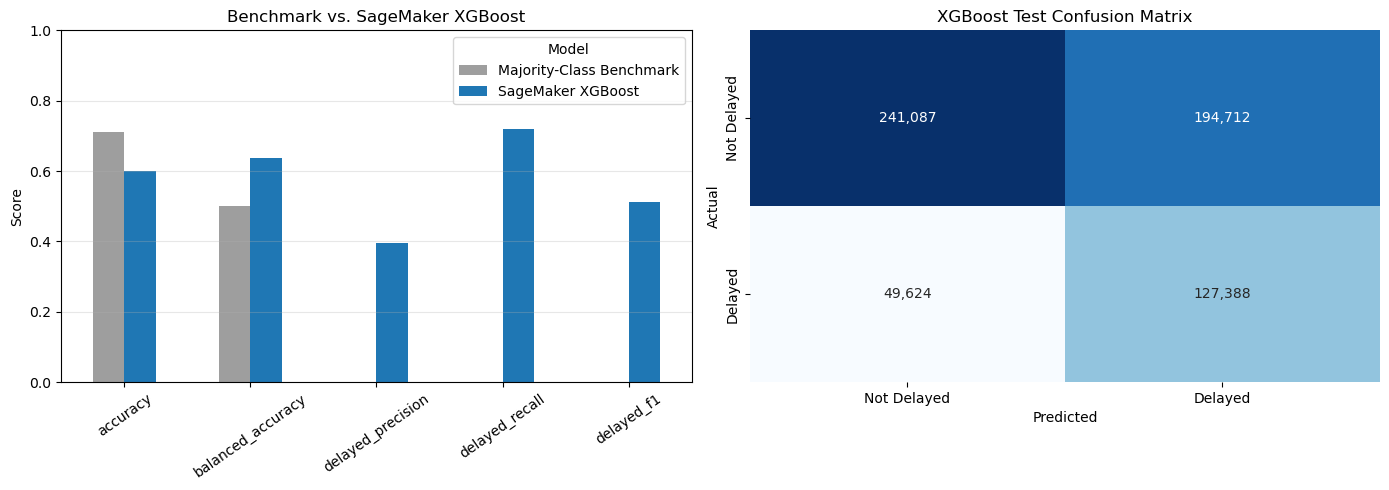

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "delayed_precision",
    "delayed_recall",
    "delayed_f1"
]

plot_data = comparison_results.set_index("model")[metric_names].T
plot_data.plot(kind="bar", ax=axes[0], color=["#9e9e9e", "#1f77b4"])

axes[0].set_title("Benchmark vs. SageMaker XGBoost")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="Model")
axes[0].grid(axis="y", alpha=0.3)

sns.heatmap(
    confusion_matrix(
        test_predictions["actual"],
        test_predictions["predicted"]
    ),
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    xticklabels=["Not Delayed", "Delayed"],
    yticklabels=["Not Delayed", "Delayed"],
    ax=axes[1]
)

axes[1].set_title("XGBoost Test Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Feature Importance

The trained XGBoost model is inspected to determine which of the eight input
features contributed most to its predictions.

/tmp/ipykernel_1530/3096021429.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(temp_dir)


,feature,gain,importance_pct
4,scheduled_departure_hour,1139.26,31.78
5,scheduled_arrival_hour,697.45,19.45
1,day_of_month,526.69,14.69
0,month,474.96,13.25
2,day_of_week,391.39,10.92
3,is_weekend,166.72,4.65
7,distance,97.12,2.71
6,scheduled_duration,91.43,2.55


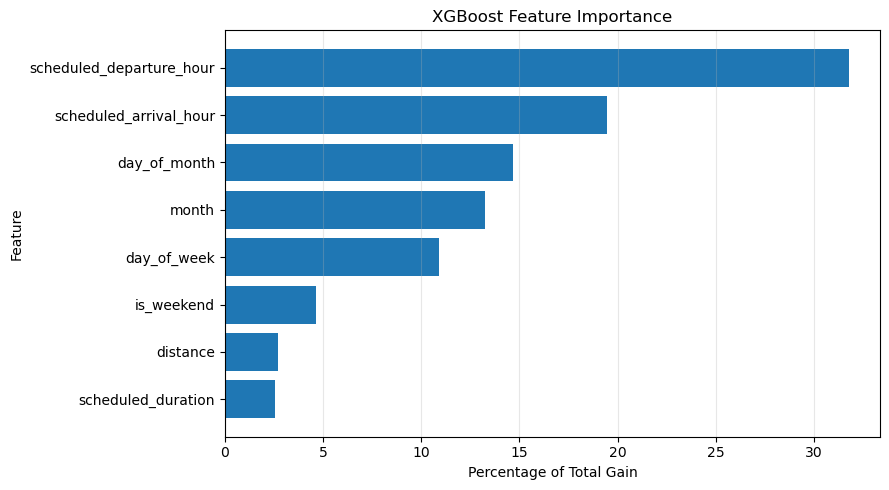

In [23]:
import os
import tarfile
import tempfile
from urllib.parse import urlparse

import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

artifact_uri = model_artifact
parsed_uri = urlparse(artifact_uri)

artifact_bucket = parsed_uri.netloc
artifact_key = parsed_uri.path.lstrip("/")

with tempfile.TemporaryDirectory() as temp_dir:
    artifact_file = os.path.join(temp_dir, "model.tar.gz")

    s3_client.download_file(
        artifact_bucket,
        artifact_key,
        artifact_file
    )

    with tarfile.open(artifact_file, "r:gz") as archive:
        archive.extractall(temp_dir)

    extracted_files = [
        os.path.join(temp_dir, filename)
        for filename in os.listdir(temp_dir)
        if filename != "model.tar.gz"
    ]

    booster = xgb.Booster()

    for candidate_file in extracted_files:
        try:
            booster.load_model(candidate_file)
            model_file = candidate_file
            break
        except xgb.core.XGBoostError:
            continue
    else:
        raise FileNotFoundError("XGBoost model file was not found.")

raw_importance = booster.get_score(importance_type="gain")

feature_importance = {}

for feature_name, importance in raw_importance.items():
    if feature_name.startswith("f") and feature_name[1:].isdigit():
        feature_index = int(feature_name[1:])
        readable_name = model_features[feature_index]
    else:
        readable_name = feature_name

    feature_importance[readable_name] = importance

importance_df = (
    pd.DataFrame(
        feature_importance.items(),
        columns=["feature", "gain"]
    )
    .sort_values("gain", ascending=False)
)

importance_df["importance_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum() * 100
)

display(importance_df.round(2))

plt.figure(figsize=(9, 5))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance_pct"][::-1],
    color="#1f77b4"
)
plt.title("XGBoost Feature Importance")
plt.xlabel("Percentage of Total Gain")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

Scheduled departure hour was the most influential feature, accounting for
31.78% of the model’s total gain. Scheduled arrival hour was second at 19.45%.
This indicates that the time of day when a flight is scheduled has a strong
relationship with delay risk.

Calendar features were also useful. Day of month, month and day of week
contributed 14.69%, 13.25% and 10.92%, respectively. This suggests that delay
patterns vary across different days and periods of the year. Distance and
scheduled duration had the lowest importance, contributing less than 3% each.

Feature importance describes how much the model used each variable to improve
its decision trees. It does not prove that any feature directly causes flight
delays.